In [17]:
#!pip install -q -U google-generativeai
#!pip install -U -q google-generativeai langchain langchain-google-genai langchain_community pypdf chromadb

In [18]:
!pip install -U langchain langchain-community sentence-transformers faiss-cpu pypdf

In [19]:
!pip install -qU langchain langchain-community langchain-text-splitters faiss-cpu langchain-google-genai PyMuPDF langchain-groq langgraph

In [20]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import os
from google.colab import userdata

# Simpan API key di: Colab Secrets (🔑) → nama secret: GEMINI
GEMINI = userdata.get('GEMINI')
os.environ["GOOGLE_API_KEY"] = GEMINI

# text-embedding-004 adalah model embedding terbaru dari Google
# menghasilkan vector 768 dimensi per teks
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2", output_dimensionality=768)

In [21]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

# embed_query("hello world") menghasilkan vector — kita ambil panjangnya
# untuk menentukan dimensi index FAISS
# IndexFlatL2 = cari vector terdekat dengan jarak Euclidean (L2)
index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

# Inisialisasi FAISS Vector Store
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),  # simpan dokumen di memori (bukan disk)
    index_to_docstore_id={},      # mapping index FAISS ke ID dokumen
)

In [22]:
from uuid import uuid4
from langchain_core.documents import Document

document_1 = Document(
    page_content="""
    Padi merupakan tanaman pangan utama di Indonesia.
    Tanaman ini membutuhkan ketersediaan air yang cukup
    selama fase vegetatif.
    """,
    metadata={"source": "budidaya_padi"}
)

document_2 = Document(
    page_content="""
    Hama wereng coklat dapat menyebabkan gagal panen.
    Pengendalian dilakukan dengan penggunaan varietas tahan
    dan rotasi tanaman.
    """,
    metadata={"source": "hama_wereng"}
)

document_3 = Document(
    page_content="""
    Penyakit blas pada padi disebabkan oleh jamur
    Magnaporthe oryzae dan dapat menyerang daun,
    batang, serta malai.
    """,
    metadata={"source": "penyakit_blas"}
)

document_4 = Document(
    page_content="""
    Pemupukan nitrogen membantu pertumbuhan daun
    dan batang tanaman, tetapi penggunaan berlebihan
    dapat meningkatkan risiko serangan hama.
    """,
    metadata={"source": "pemupukan"}
)

document_5 = Document(
    page_content="""
    Tanaman cabai tumbuh optimal pada suhu antara
    24 hingga 30 derajat Celsius dengan drainase tanah
    yang baik.
    """,
    metadata={"source": "budidaya_cabai"}
)

document_6 = Document(
    page_content="""
    Curah hujan yang terlalu tinggi dapat meningkatkan
    risiko penyakit pada tanaman hortikultura.
    """,
    metadata={"source": "cuaca"}
)

document_7 = Document(
    page_content="""
    Penggunaan pupuk organik dapat meningkatkan
    kesuburan tanah dan aktivitas mikroorganisme.
    """,
    metadata={"source": "pupuk_organik"}
)

document_8 = Document(
    page_content="""
    Jagung memerlukan sinar matahari penuh selama
    masa pertumbuhan agar menghasilkan tongkol yang optimal.
    """,
    metadata={"source": "budidaya_jagung"}
)

document_9 = Document(
    page_content="""
    Sistem irigasi tetes dapat menghemat penggunaan air
    hingga 50 persen dibandingkan metode konvensional.
    """,
    metadata={"source": "irigasi"}
)

document_10 = Document(
    page_content="""
    Panen padi umumnya dilakukan ketika 90 hingga 95 persen
    gabah telah menguning.
    """,
    metadata={"source": "panen_padi"}
)

documents = [
    document_1,
    document_2,
    document_3,
    document_4,
    document_5,
    document_6,
    document_7,
    document_8,
    document_9,
    document_10
]

# Membuat ID unik
uuids = [str(uuid4()) for _ in range(len(documents))]

# Menambahkan ke vector store
vector_store.add_documents(
    documents=documents,
    ids=uuids
)

print("10 dokumen pertanian berhasil ditambahkan ke vector store")

10 dokumen pertanian berhasil ditambahkan ke vector store


In [23]:
results = vector_store.similarity_search(
    "Bagaimana cara mengendalikan hama pada tanaman padi?",
    k=2,
    filter={"source": {"$eq": "hama_wereng"}}
)

for res in results:
    print(f"* {res.page_content}")
    print(f"Metadata: {res.metadata}")
    print("-" * 50)

* 
    Hama wereng coklat dapat menyebabkan gagal panen.
    Pengendalian dilakukan dengan penggunaan varietas tahan
    dan rotasi tanaman.
    
Metadata: {'source': 'hama_wereng'}
--------------------------------------------------


In [24]:
# Cari 3 dokumen paling relevan dari semua sumber

results = vector_store.similarity_search(
    "Bagaimana cara mengendalikan hama wereng pada tanaman padi?",
    k=3,
)

for res in results:
    print(f"* {res.page_content}")
    print(f"Metadata: {res.metadata}")
    print("-" * 50)

* 
    Hama wereng coklat dapat menyebabkan gagal panen.
    Pengendalian dilakukan dengan penggunaan varietas tahan
    dan rotasi tanaman.
    
Metadata: {'source': 'hama_wereng'}
--------------------------------------------------
* 
    Padi merupakan tanaman pangan utama di Indonesia.
    Tanaman ini membutuhkan ketersediaan air yang cukup
    selama fase vegetatif.
    
Metadata: {'source': 'budidaya_padi'}
--------------------------------------------------
* 
    Penyakit blas pada padi disebabkan oleh jamur
    Magnaporthe oryzae dan dapat menyerang daun,
    batang, serta malai.
    
Metadata: {'source': 'penyakit_blas'}
--------------------------------------------------


In [25]:
# Simpan index ke folder lokal
vector_store.save_local("faiss_index")

In [26]:
# Muat kembali dari disk
# allow_dangerous_deserialization=True diperlukan karena FAISS menggunakan pickle
new_vector_store = FAISS.load_local(
    "faiss_index", embeddings, allow_dangerous_deserialization=True
)

docs = new_vector_store.similarity_search("qux")
for res in docs:
    print(f"* {res.page_content} [{res.metadata}]")

* 
    Curah hujan yang terlalu tinggi dapat meningkatkan
    risiko penyakit pada tanaman hortikultura.
     [{'source': 'cuaca'}]
* 
    Penggunaan pupuk organik dapat meningkatkan
    kesuburan tanah dan aktivitas mikroorganisme.
     [{'source': 'pupuk_organik'}]
* 
    Sistem irigasi tetes dapat menghemat penggunaan air
    hingga 50 persen dibandingkan metode konvensional.
     [{'source': 'irigasi'}]
* 
    Tanaman cabai tumbuh optimal pada suhu antara
    24 hingga 30 derajat Celsius dengan drainase tanah
    yang baik.
     [{'source': 'budidaya_cabai'}]


In [27]:
from langchain_text_splitters import CharacterTextSplitter
from langchain_core.documents import Document
import fitz  # PyMuPDF

In [28]:
def extract_text_from_pdf(pdf_path):
    """Mengekstrak teks dari PDF menggunakan PyMuPDF"""
    doc = fitz.open(pdf_path)
    text = "\n".join([page.get_text() for page in doc])
    return text

# Ganti path ini dengan PDF kamu
pdf_text = extract_text_from_pdf("/content/pertanian.pdf")
print(f"Total karakter: {len(pdf_text)}")
print("\nPreview 500 karakter pertama:")
print(pdf_text[:500])

Total karakter: 37686

Preview 500 karakter pertama:
-DADI MAKMUR-
KIAT
BUDIDAYA
CABAI
MULAI DARI BENIH, PENANAMAN
PANEN RAYA, HINGGA
PEMASARAN

DAFTAR ISI
Asal-Usul Cabai
Jenis - Jenis Cabai
Pemilihan Benih
Pembibitan
Proses Pengolahan Tanah
Persiapan Lahan
Penanaman
2
3
4
5
6
1
7

DAFTAR ISI
Pemupukan
Perawatan
Pengairan
Penyiangan Gulma
Panen
Pemasaran/Jual hasil 
Panen
8
9
10
11
12
13

Pembuka
Apa yang ada di benak kita jika mendengar kata Cabai?
Ya, pertama mungkin kebanyakan dari akan menjawab dengan “Cabai
Mahal”. 
Kita semua tahu, bahwa ca


In [29]:
splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_text(pdf_text)
print(f"Total chunks: {len(chunks)}")

Total chunks: 47


In [30]:
# Preview setiap chunk (100 karakter pertama saja)
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk[:100]}...")

Chunk 1: -DADI MAKMUR-
KIAT
BUDIDAYA
CABAI
MULAI DARI BENIH, PENANAMAN
PANEN RAYA, HINGGA
PEMASARAN
DAFTAR IS...
Chunk 2: Petani Cabai khusus untuk Anda yang semangat belajar, karena dengan
belajar dan mencoba hal barulah ...
Chunk 3: legendaris Christoper Columbus lah kemudian yang pertama kali berjasa 
menyebarluaskannya ke Italia,...
Chunk 4: terdapat vitamin c yang cukup tinggi pada buah cabai. Namun, meskipun 
memiliki manfaat bagi kesehat...
Chunk 5: Subkingdom : Trachebionta (Tumbuhan berpembuluh)
Super Divisi : Spermatophyta (Menghasilkan biji)
Di...
Chunk 6: menghadap langit (ngathur, Jawa red). Warnaya hijau ketika muda dan 
akan berwarna merah tua apabila...
Chunk 7: bird's eye chili pepper. Di Indonesia, cabai rawit biasanya digunakan 
sebagai bahan dasar untuk mem...
Chunk 8: Buah cabai ini akan berwarna ungu awalnya, kemudian akan berubah 
menjadi kuning dan oranye, apabila...
Chunk 9: biasanya jalapeno juga tersedia dalam variasi keringnya yang disebut 
dengan chipotles.

In [31]:
# Inisialisasi FAISS baru untuk dokumen PDF ini
index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [32]:
# Bungkus setiap chunk sebagai Document object
documents = [Document(page_content=chunk) for chunk in chunks]

# Generate UUID untuk setiap dokumen
uuids = [str(uuid4()) for _ in range(len(documents))]

# Embed dan simpan ke FAISS
vector_store.add_documents(documents=documents, ids=uuids)
print(f"{len(documents)} chunks berhasil disimpan ke vector store")

47 chunks berhasil disimpan ke vector store


In [33]:
# Simpan ke disk agar tidak perlu embed ulang
vector_store.save_local("faiss_index")
print("Index tersimpan di folder faiss_index/")

Index tersimpan di folder faiss_index/


In [34]:
from langchain_core.documents import Document
from typing import List, TypedDict
from langchain_groq import ChatGroq

# State adalah "tas" yang dibawa sepanjang perjalanan graph
# Setiap node bisa membaca dan mengisi field di State
class State(TypedDict):
    question: str           # pertanyaan dari user
    context: List[Document] # hasil retrieve dari FAISS
    answer: str             # jawaban final dari LLM

In [35]:
from langsmith.client import Client

# Tarik prompt RAG standar dari LangChain Hub
# Prompt ini punya dua variabel: {context} dan {question}
client = Client()
prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

# Lihat isi prompt-nya
example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print("Isi RAG prompt:")
print(example_messages[0].content)

Isi RAG prompt:
You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


In [36]:
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [37]:
# Inisialisasi LLM — pakai Llama 3.3 70B via Groq (gratis, cepat)
# Groq menyediakan inference engine yang sangat cepat untuk model open-source

from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

MODEL = 'llama-3.3-70b-versatile'

llm = ChatGroq(
    temperature=0,  # 0 = deterministik, cocok untuk Q&A faktual
    model=MODEL     # bisa diganti model lain seperti gemini atau GPT
)

In [38]:
# Node 1: Retrieve — ambil dokumen relevan dari FAISS
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


# Node 2: Generate — buat jawaban berdasarkan context + question
def generate(state: State):
    # Gabungkan semua chunk yang diambil jadi satu string konteks
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    # Isi template prompt dengan konteks dan pertanyaan
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    # Kirim ke LLM
    response = llm.invoke(messages)
    return {"answer": response.content}

In [39]:
from langgraph.graph import START, StateGraph

# Definisikan graph: retrieve dulu, lalu generate
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

print("Graph berhasil dikompilasi!")

Graph berhasil dikompilasi!


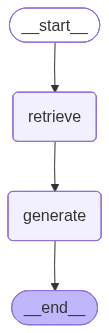

In [40]:
# Visualisasi alur graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
result = graph.invoke({"question": "Apa itu pertanian?"})

print("=== Context yang diambil dari FAISS ===")
for i, doc in enumerate(result["context"]):
    print(f"\nChunk {i+1}:")
    print(doc.page_content[:200] + "...")

print("\n=== Jawaban LLM ===")
print(result["answer"])

=== Context yang diambil dari FAISS ===

Chunk 1:
tanaman agar tahu betul akan masalah yang timbul dan tindakan yang 
akan dilakukan.
3.
Evaluasi
Jangan lupa untuk evaluasi dan belajar dari pengalaman agar 
semakin mahir dan sigap di masa depan.
4.
A...

Chunk 2:
hari. Di samping itu, pupuk pelengkap cair (PPC) Metalik (1 cc/l) 
diberikan dengan cara disemprotkan pada tanaman.
Penanaman Cabai Di Luar Musim.
Cara Ekstrim, Hasil Maksimal
Pastinya Anda sudah tahu...

Chunk 3:
air setiap hari dan dilakukan pagi hari untuk menjaga kelembaban tanah 
hingga sampai malam hari. Selama persemaian bila didapati gulma, maka 
lakukan pembersihan dengan tangan, dan bila terlihat ada ...

Chunk 4:
tanaman cabai tumbuh ditanah yang becek juga akan berpengaruh pada 
pertumbuhannya dan mudah terkena penyakit terutama yang disebabkan 
oleh jamur. Curah hujan yang terlalu berlebihan juga membuat bun...

=== Jawaban LLM ===
Pertanian adalah kegiatan yang meliputi penanaman, perawatan, dan pemanenan tanaman

In [43]:
result = graph.invoke({
    "question": "Bagaimana cara mengendalikan hama wereng pada tanaman padi?"
})

print(result["answer"])

Untuk mengendalikan hama wereng pada tanaman padi, perlu dilakukan evaluasi dan tindakan yang tepat. Namun, informasi spesifik tentang cara mengendalikan hama wereng tidak disebutkan dalam konteks yang diberikan. Oleh karena itu, saya tidak dapat memberikan jawaban yang akurat.


In [44]:
chat_history = []

question = "Apa itu hama wereng?"

result = graph.invoke({
    "question": question,
    "chat_history": chat_history
})

chat_history.append(
    ("user", question)
)

chat_history.append(
    ("assistant", result["answer"])
)

In [45]:
result = graph.invoke({
    "question": question,
    "chat_history": chat_history
})

print(result)

{'question': 'Apa itu hama wereng?', 'context': [Document(id='1663832e-c693-444a-9238-663b6947bc19', metadata={}, page_content='tanaman cabai tumbuh ditanah yang becek juga akan berpengaruh pada \npertumbuhannya dan mudah terkena penyakit terutama yang disebabkan \noleh jamur. Curah hujan yang terlalu berlebihan juga membuat bunga cabai \nberguguran dan buahnya akan banyak yang membusuk.\nPemilihan waktu tanam juga berbeda menurut lokasi dan tipe lahan. Untuk \nlahan yang kering atau tegalan sebaiknya penanaman dilakukan pada awal \nmusim hujan, sementara untuk lahan sawah penanaman dilakukan pada \nakhir musim hujan.\nPenanaman Cabai.\nWAKTU TANAM, DAN \nPENANAMAN CABAI\nPemasangan mulsa bertujuan untuk menjaga struktur tanah agar tetap \ngembur, memelihara kelembaban dan temperatur tanah, menghindari \npencucian unsur hara dikala hujan, menekan perkembangan gulma, dan \nterhindar dari erosi tanah.\nPlastik hitam perak dapat diganti dengan plastik putih transparan, atau \njerami. Namu

In [46]:
chat_history = []

question = "Apa itu hama wereng?"

result = graph.invoke({
    "question": question,
    "chat_history": chat_history
})

# Tampilkan jawaban
print("Jawaban:")
print(result["answer"])

# Simpan ke history
chat_history.append(
    ("user", question)
)

chat_history.append(
    ("assistant", result["answer"])
)

# Tampilkan history
print("\nChat History:")
for role, message in chat_history:
    print(f"{role}: {message}")

Jawaban:
Hama wereng tidak disebutkan secara spesifik dalam konteks yang diberikan. Namun, beberapa hama yang disebutkan dalam konteks tersebut adalah trips, tungau, dan virus. Jika Anda mencari informasi tentang hama wereng, saya tidak memiliki informasi yang cukup dari konteks yang diberikan.

Chat History:
user: Apa itu hama wereng?
assistant: Hama wereng tidak disebutkan secara spesifik dalam konteks yang diberikan. Namun, beberapa hama yang disebutkan dalam konteks tersebut adalah trips, tungau, dan virus. Jika Anda mencari informasi tentang hama wereng, saya tidak memiliki informasi yang cukup dari konteks yang diberikan.


In [47]:

chat_history = []

while True:
    question = input("Anda: ")

    if question.lower() == "keluar":
        break

    result = graph.invoke({
        "question": question,
        "chat_history": chat_history
    })

    print("\nAgriAssist:")
    print(result["answer"])

    chat_history.append(("user", question))
    chat_history.append(("assistant", result["answer"]))

Anda: apa itu ereng

AgriAssist:
Apa itu ereng tidak disebutkan dalam konteks yang diberikan. Konteks tersebut membahas tentang perawatan tanah, penanaman cabai, dan jenis-jenis cabai, tetapi tidak menyebutkan apa itu ereng. Oleh karena itu, saya tidak tahu apa itu ereng.
Anda: wereng

AgriAssist:
I don't know what "wereng" refers to. The provided context does not mention the term "wereng". It appears to be related to farming and planting, but without more information, I cannot provide a specific answer.
Anda: keluar


In [48]:
!pip install -q langchain-community duckduckgo-search
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.6 MB/s eta 0:00:00


In [49]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

hasil = search.invoke(
    "harga gabah terbaru di Indonesia"
)

print(hasil)

January 13, 2026 - Antara/Umarul Faruq · KEPALA Badan ... pada tahun ini. Harga pembelian pemerintah (HPP) untuk gabah kering panen adalah Rp 6.500 per kilogram.... January 14, 2026 - Harusnya dinaikkan," kata Henry kepada CNBC Indonesia, Rabu (14/1/2026). SPI pun mengusulkan HPP gabah dinaikkan menjadi Rp7.000 per kg. 4 weeks ago - Harga gabah di tingkat petani naik menjadi Rp7.200-7.300 per kg, melebihi HPP Rp6.500. Bulog tetap akan membeli gabah jika pedagang tidak melakukannya. April 8, 2026 - "Kemudian, HPP dijaga. Harga Pembelian Pemerintah untuk gabah itu Rp6.500. Kesejahteraan petani, peningkatannya tertinggi selama Republik Indonesia merdeka," tutur Amran. May 7, 2026 - Kalau punya lantai jemur dan bisa mengeringkan gabah ke kadar air GKG, selisih harga Rp 800-1.200/kg sangat signifikan. Cek juga harga di beberapa pengepul dan penggilingan terdekat sebelum memutuskan – perbedaan harga antar pembeli bisa mencapai ...


In [50]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

def web_search(query):
    return search_tool.invoke(query)

In [51]:
print(
    web_search(
        "harga pupuk urea terbaru"
    )
)

Oct 22, 2025 · Jakarta, Beritasatu.com - Pemerintah menetapkan penurunan harga pupuk secara nasional mulai Rabu (22/10/2025) hari ini. Pupuk Urea yang sebelumnya dijual Rp 2.250 per kilogram kini turun menjadi Rp 1.800 per kilogram, sehingga harga per sak 50 kilogram turun dari Rp 112.500 menjadi Rp 90.000. Mau cek harga Pupuk Urea Non Subsidi 50 Kg terbaru hari ini? Kamu bisa cek Daftar Harga Terbaru Pupuk Urea Non Subsidi 50 Kg Juni 2026 yang bisa diurutkan dari harga yang termurah! Penetapan HET pupuk subsidi 2025 tetapkan harga Urea Rp1.8000/kg, NPK Rp1.840/kg, ZA Rp1.360/kg, NPK untuk Kakao Rp2.640/kg dan Organik Rp640/kg demi melindungi petani dan distribusi adil. Sep 9, 2025 · Bandingkan harga pupuk urea non subsidi terbaru berdasarkan merek, lokasi, distributor, dan perbedaan dengan pupuk subsidi. Perbandingan harga dan spesifikasi untuk pupuk urea dari total 5.081 produk. Temukan juga Pupuk Urea,urea pupuk,pupuk urea gresik,pupuk urea denpasar,pupuk urea kaltim. Perbandingan h

In [52]:
graph.invoke({
    "question": question
})

{'question': 'keluar',
 'context': [Document(id='67422373-5688-47f2-9986-d5c8a1045301', metadata={}, page_content='-DADI MAKMUR-\nKIAT\nBUDIDAYA\nCABAI\nMULAI DARI BENIH, PENANAMAN\nPANEN RAYA, HINGGA\nPEMASARAN\nDAFTAR ISI\nAsal-Usul Cabai\nJenis - Jenis Cabai\nPemilihan Benih\nPembibitan\nProses Pengolahan Tanah\nPersiapan Lahan\nPenanaman\n2\n3\n4\n5\n6\n1\n7\nDAFTAR ISI\nPemupukan\nPerawatan\nPengairan\nPenyiangan Gulma\nPanen\nPemasaran/Jual hasil \nPanen\n8\n9\n10\n11\n12\n13\nPembuka\nApa yang ada di benak kita jika mendengar kata Cabai?\nYa, pertama mungkin kebanyakan dari akan menjawab dengan “Cabai\nMahal”. \nKita semua tahu, bahwa cabai merupakan salah satu komoditas yang \npangsa pasarnya besar dan luas, pada tahun 2013 saja rata-rata konsumsi\n5 kg/kapita/ tahun. \nTantangannya adalah, bagaimana caranya agar produksi cabai meningkat\nsehingga kita petani juga untung banyak?\nOleh karena itu, kami dari Dadi Makmur menyusun ebook Kitab Sakti\nPetani Cabai khusus untuk Anda y

In [53]:
def agri_assistant(question):

    # Pertanyaan yang membutuhkan data terbaru
    keywords = [
        "harga",
        "hari ini",
        "terbaru",
        "cuaca",
        "berita"
    ]

    if any(
        k in question.lower()
        for k in keywords
    ):
        return web_search(question)

    else:
        result = graph.invoke(
            {"question": question}
        )
        return result["answer"]

In [54]:
print(
    agri_assistant(
        "Apa itu penyakit blas?"
    )
)

Penyakit blas tidak disebutkan secara spesifik dalam konteks yang diberikan. Konteks tersebut membahas tentang penanaman cabai, perawatan, dan manfaatnya, tetapi tidak menyebutkan penyakit blas. Oleh karena itu, saya tidak dapat memberikan jawaban yang akurat tentang penyakit blas.


In [55]:
print(
    agri_assistant(
        "Harga gabah hari ini"
    )
)

Dapatkan informasi detail mengenai harga Gabah hari ini, termasuk grafik, analisis teknikal, data historis, berita dan sebagainya. Jan 2, 2025 · - Mulai Januari 2020 gabah 'Kualitas Rendah' diganti dengan 'Luar Kualitas' sesuai dengan Inpres RI Nomor 5 Tahun 2015 - Mulai April 2020, terdapat perubahan Harga Pembelian Pemerintah (HPP) berdasarkan Permendag Nomor 24 Tahun 2020 berlaku mulai 19 Maret 2020 Sistem Informasi Harga Komoditi Bappebti Memberikan informasi harga-harga komoditi di seluruh Indonesia mulai dari level terbawah hingga level teratas dalam siklus penjualan komoditi. Harga ini diperoleh dari perwakilan setiap level penjualan yang bekerja sama dengan BAPPEBTI. May 12, 2026 · Panduan harga gabah GKP dan GKG terkini: HPP resmi pemerintah 2026, faktor yang mempengaruhi harga pasar, dan strategi timing jual yang menguntungkan. Jan 13, 2025 · Pemerintah menetapkan HPP gabah Rp 6.500/kg dan beras Rp 12.000/kg mulai 15 Januari 2025. Kebijakan ini bertujuan menyesuaikan biaya pr

In [56]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun()

print(
    search.invoke(
        "harga gabah terbaru Indonesia"
    )
)

Baca: Daftar Harga Rempah Terbaru di Indonesia. Kemudian harga gabah kering minggu ini memang mengalami grafik naik turun jika kita bandingkan tahun 2015 namun juga mengalami peningkatan tahun ini. Keywords: harga gabah 29 April 2026, harga gabah Rp7.500, mencegah penyakit potong leher padi, fungisida Explore DGW, update harga gabah terbaru, tips petani padi, perlindungan tanaman padi, harga gabah daerah, penggunaan fungisida saat generatif, hasil panen padi. CNN Indonesia. Senin, 11 Mei 2026 18:03 WIB. Bagikan: icon-facebook icon-x. url telah tercopy."Perlu kami laporkan juga, tingginya harga beras dalam kurun waktu dua minggu ini disinyalir karena tingginya harga gabah di pasar. Zulhas Sebut Harga Gabah Stabil karena Begitu Kapolri Tampil, Tengkulak "Tiarap". News.Cegah Korupsi, Bulog Terapkan Pembayaran Gabah Non-Tunai. Money. 2 Januari 2026. Harga Gabah Naik, Zulhas Klaim Tengkulak Kini Tak Bisa. Harga gabah kering di tingkat petani saat ini naik, dari harga sebelumnya Rp 6800/kg m

In [57]:
def route_question(question):

    web_keywords = [
        "harga",
        "hari ini",
        "terbaru",
        "berita",
        "cuaca"
    ]

    if any(
        keyword in question.lower()
        for keyword in web_keywords
    ):
        return "web"

    return "rag"

In [58]:
def agri_assistant(question):

    route = route_question(question)

    print("Tool yang dipilih:", route)

    if route == "web":

        return web_search(question)

    result = graph.invoke({
        "question": question
    })

    return result["answer"]

In [59]:
print(
    agri_assistant(
        "Harga pupuk urea hari ini"
    )
)

Tool yang dipilih: web
Oct 22, 2025 · Jakarta, Beritasatu.com - Pemerintah menetapkan penurunan harga pupuk secara nasional mulai Rabu (22/10/2025) hari ini. Pupuk Urea yang sebelumnya dijual Rp 2.250 per kilogram kini turun menjadi Rp 1.800 per kilogram, sehingga harga per sak 50 kilogram turun dari Rp 112.500 menjadi Rp 90.000. Penetapan HET pupuk subsidi 2025 tetapkan harga Urea Rp1.8000/kg, NPK Rp1.840/kg, ZA Rp1.360/kg, NPK untuk Kakao Rp2.640/kg dan Organik Rp640/kg demi melindungi petani dan distribusi adil. “Ini adalah berita gembira. Harga pupuk turun 20 persen, berlaku mulai hari ini. Ini tidak pernah terjadi sepanjang sejarah,” ujar Amran. Ia menyebutkan penurunan harga pupuk subsidi berlaku untuk dua jenis utama, yakni Urea dan NPK. Untuk pupuk Urea, harga sebelumnya sebesar Rp2.250 per kilogram kini turun menjadi Rp1.800 per kilogram. Oct 23, 2025 · Cara mendapatkan pupuk bersubsidi Dilansir dari website Pupuk-Indonesia.com, pupuk subsidi adalah pupuk yang Harga Eceran Ter

In [60]:
print(
    agri_assistant(
        "Apa itu penyakit blas?"
    )
)

Tool yang dipilih: rag
Penyakit blas tidak disebutkan secara spesifik dalam konteks yang diberikan. Konteks tersebut membahas tentang penanaman cabai, perawatan, dan manfaatnya, tetapi tidak menyebutkan penyakit blas. Oleh karena itu, saya tidak dapat memberikan jawaban yang akurat tentang penyakit blas.


In [61]:
def agri_assistant(question):

    web_keywords = [
        "harga",
        "hari ini",
        "terbaru",
        "berita",
        "cuaca"
    ]

    if any(
        keyword in question.lower()
        for keyword in web_keywords
    ):
        return web_search(question)

    result = graph.invoke({
        "question": question
    })

    return result["answer"]

In [62]:
print(
    agri_assistant(
        "Apa itu hama wereng?"
    )
)

Hama wereng tidak disebutkan dalam konteks yang diberikan. Konteks tersebut membahas tentang penanaman cabai, perawatan, dan pengendalian hama, tetapi tidak secara spesifik menyebutkan "hama wereng". Oleh karena itu, saya tidak dapat memberikan jawaban yang akurat tentang apa itu hama wereng.


In [63]:
print(
    agri_assistant(
        "Harga pupuk urea hari ini"
    )
)

October 22, 2025 - Penurunan harga ini berlaku untuk seluruh jenis pupuk subsidi yang digunakan petani. Berikut daftar harga pupuk subsidi setelah turun 20%: Pupuk Urea dari Rp2.250 per kilogram menjadi Rp1.800 per kilogram April 16, 2026 - Jakarta, SAWIT INDONESIA – Harga ... Dilansir dari Anadolu pada Kamis (16/4/20269, harga urea meningkat sekitar 86 persen dibandingkan dengan awal tahun ini.... April 24, 2026 - Update harga pupuk hari ini, 24 April 2026: Ca Mau Urea 675.000 VND/karung, DAP Rusia 1.245.000 VND/karung, Binh Dien NPK 20-20-15 960.000 VND/karung April 2, 2026 - Jakarta, CNBC Indonesia - Harga pupuk urea global melonjak tajam di tengah memanasnya konflik di kawasan Timur Tengah. Kenaikan ini bahkan mencapai dua kali lipat, dipicu terganggunya jalur distribusi pupuk dunia yang selama ini sangat bergantung oleh Selat Hormuz. Direktur Utama PT Pupuk Indonesia (Persero), Rahmad Pribadi mengungkapkan, konflik di Selat Hormuz berdampak besar terhadap perdagangan pupuk global.

In [64]:
chat_history = []

while True:

    question = input("Anda: ")

    if question.lower() == "keluar":
        break

    answer = agri_assistant(question)

    print("\nAgriAssist:")
    print(answer)

    chat_history.append(
        ("user", question)
    )

    chat_history.append(
        ("assistant", answer)
    )

Anda: keluar


In [66]:
%load_ext sql
%sql sqlite:///agriassist.db

In [67]:
%%sql

-- =========================
-- TABEL PUPUK
-- =========================
CREATE TABLE IF NOT EXISTS pupuk (
    pupuk_id INTEGER PRIMARY KEY AUTOINCREMENT,
    nama_pupuk VARCHAR(255) NOT NULL,
    harga INTEGER NOT NULL,
    fungsi TEXT
);

-- =========================
-- TABEL OBAT PERTANIAN
-- =========================
CREATE TABLE IF NOT EXISTS obat_pertanian (
    obat_id INTEGER PRIMARY KEY AUTOINCREMENT,
    nama_obat VARCHAR(255) NOT NULL,
    kategori VARCHAR(100) NOT NULL,
    harga INTEGER NOT NULL,
    kegunaan TEXT
);

-- =========================
-- TABEL HAMA DAN PENYAKIT
-- =========================
CREATE TABLE IF NOT EXISTS hama_penyakit (
    hama_id INTEGER PRIMARY KEY AUTOINCREMENT,
    nama_hama VARCHAR(255) NOT NULL,
    gejala TEXT,
    penanganan TEXT
);

-- =========================
-- DATA PUPUK
-- =========================
INSERT INTO pupuk (nama_pupuk, harga, fungsi)
VALUES
('Urea', 120000, 'Memacu pertumbuhan daun dan batang'),
('NPK Phonska', 145000, 'Meningkatkan pertumbuhan dan hasil panen'),
('ZA', 95000, 'Menambah unsur nitrogen dan sulfur'),
('KCl', 170000, 'Meningkatkan kualitas buah dan ketahanan tanaman');

-- =========================
-- DATA OBAT PERTANIAN
-- =========================
INSERT INTO obat_pertanian (nama_obat, kategori, harga, kegunaan)
VALUES
('Decis', 'Insektisida', 55000, 'Mengendalikan hama wereng'),
('Curacron', 'Insektisida', 85000, 'Mengendalikan ulat dan serangga'),
('Score', 'Fungisida', 75000, 'Mengendalikan penyakit blas'),
('Antracol', 'Fungisida', 68000, 'Mengendalikan penyakit akibat jamur');

-- =========================
-- DATA HAMA DAN PENYAKIT
-- =========================
INSERT INTO hama_penyakit (nama_hama, gejala, penanganan)
VALUES
(
    'Wereng Coklat',
    'Daun menguning dan tanaman layu',
    'Gunakan varietas tahan dan insektisida sesuai dosis'
),
(
    'Penyakit Blas',
    'Muncul bercak berbentuk belah ketupat pada daun',
    'Gunakan fungisida dan atur kelembapan lahan'
),
(
    'Ulat Grayak',
    'Daun berlubang dan habis dimakan',
    'Pengendalian mekanis atau insektisida'
);

 * sqlite:///agriassist.db
Done.
Done.
Done.
4 rows affected.
4 rows affected.
3 rows affected.


[]

In [72]:
import sqlite3

db_file = "agriassist.db"

In [73]:
import sqlite3

db_file = "agriassist.db"

def describe_table(table_name: str) -> list[tuple[str, str]]:
    """
    Melihat struktur tabel.

    Returns:
        List[(nama_kolom, tipe_data)]
    """

    print(" - DB CALL: describe_table")

    with sqlite3.connect(db_file) as conn:
        cursor = conn.cursor()

        cursor.execute(
            f"PRAGMA table_info({table_name});"
        )

        schema = cursor.fetchall()

        return [
            (col[1], col[2])
            for col in schema
        ]

In [74]:
describe_table("pupuk")

 - DB CALL: describe_table


[('pupuk_id', 'INTEGER'),
 ('nama_pupuk', 'VARCHAR(255)'),
 ('harga', 'INTEGER'),
 ('fungsi', 'TEXT')]

In [75]:
import sqlite3

db_file = "agriassist.db"

def execute_query(sql: str):
    """
    Menjalankan query SQL SELECT
    dan mengembalikan hasilnya.
    """

    print(" - DB CALL: execute_query")

    with sqlite3.connect(db_file) as conn:
        cursor = conn.cursor()

        cursor.execute(sql)

        return cursor.fetchall()

In [76]:
execute_query("""
SELECT *
FROM pupuk
""")

 - DB CALL: execute_query


[(1, 'Urea', 120000, 'Memacu pertumbuhan daun dan batang'),
 (2, 'NPK Phonska', 145000, 'Meningkatkan pertumbuhan dan hasil panen'),
 (3, 'ZA', 95000, 'Menambah unsur nitrogen dan sulfur'),
 (4, 'KCl', 170000, 'Meningkatkan kualitas buah dan ketahanan tanaman')]

In [78]:
import sqlite3

db_file = "agriassist.db"

def list_tables():
    """Menampilkan semua tabel yang tersedia."""

    print(" - DB CALL: list_tables")

    with sqlite3.connect(db_file) as conn:
        cursor = conn.cursor()

        cursor.execute("""
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        """)

        return [row[0] for row in cursor.fetchall()]


def describe_table(table_name: str):
    """Menampilkan struktur tabel."""

    print(" - DB CALL: describe_table")

    with sqlite3.connect(db_file) as conn:
        cursor = conn.cursor()

        cursor.execute(
            f"PRAGMA table_info({table_name});"
        )

        schema = cursor.fetchall()

        return [
            (col[1], col[2])
            for col in schema
        ]


def execute_query(sql: str):
    """Menjalankan query SELECT."""

    print(" - DB CALL: execute_query")

    with sqlite3.connect(db_file) as conn:
        cursor = conn.cursor()

        cursor.execute(sql)

        return cursor.fetchall()

In [79]:
# Tools database yang tersedia
db_tools = [
    list_tables,
    describe_table,
    execute_query
]

instruction = """
You are AgriAssist, an AI assistant specialized in agriculture.

You have access to an SQL database containing information about:
- Fertilizers (pupuk)
- Agricultural pesticides and fungicides (obat_pertanian)
- Pests and plant diseases (hama_penyakit)

Your task is to answer user questions using the database tools provided.

Rules:
1. ALWAYS start by calling list_tables.
2. ALWAYS call describe_table on the relevant table before writing SQL queries.
3. NEVER assume table names or column names without checking first.
4. Use execute_query to retrieve information from the database.
5. Answer in Indonesian.
6. If the requested information is not available in the database, say so clearly.
7. Provide concise, accurate, and helpful answers.
"""

# Import library yang dibutuhkan
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

# Inisialisasi model Gemini
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0
)

# Membuat Agent
agent = create_agent(
    model=model,
    tools=db_tools,
    system_prompt=instruction
)

print("✅ SQL Agent AgriAssist berhasil dibuat")

✅ SQL Agent AgriAssist berhasil dibuat


In [81]:
execute_query("""
SELECT nama_pupuk, harga
FROM pupuk
""")

 - DB CALL: execute_query


[('Urea', 120000), ('NPK Phonska', 145000), ('ZA', 95000), ('KCl', 170000)]

In [82]:
response = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Berapa harga pupuk Urea?"
        }
    ]
})

print(response)

 - DB CALL: list_tables
 - DB CALL: describe_table
 - DB CALL: execute_query
{'messages': [HumanMessage(content='Berapa harga pupuk Urea?', additional_kwargs={}, response_metadata={}, id='a00d61b8-9c2e-44a0-9c64-105d05828d49'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'list_tables', 'arguments': '{}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec19d-756d-74a1-956b-68097deaecd2-0', tool_calls=[{'name': 'list_tables', 'args': {}, 'id': '88bd0e86-f51f-40e8-a5b3-61d121330ce9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 287, 'output_tokens': 10, 'total_tokens': 297, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='["pupuk", "sqlite_sequence", "obat_pertanian", "hama_penyakit"]', name='list_tables', id='60558c36-82e7-4731-839c-980d1cb69990', tool_call_id='88bd0e86-f51f-40e8-a5b3-61d121330ce9'), AIMessage

In [83]:
response = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Obat apa yang digunakan untuk mengendalikan hama wereng?"
        }
    ]
})

print(response)

 - DB CALL: list_tables
 - DB CALL: describe_table
 - DB CALL: execute_query
{'messages': [HumanMessage(content='Obat apa yang digunakan untuk mengendalikan hama wereng?', additional_kwargs={}, response_metadata={}, id='6b1a6a60-aa19-488f-a234-a7243300b1da'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'list_tables', 'arguments': '{}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec19d-e50d-7832-9575-6e4bc411ab84-0', tool_calls=[{'name': 'list_tables', 'args': {}, 'id': '14f30a29-6f9f-494c-bdb9-cc98f16f0a71', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 292, 'output_tokens': 10, 'total_tokens': 302, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='["pupuk", "sqlite_sequence", "obat_pertanian", "hama_penyakit"]', name='list_tables', id='0cb8207d-41b5-4ab8-b31e-d00194324261', tool_call_id='14f30a29-6f9f-494

In [86]:
response = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Apa saja isi database ini?"
        }
    ]
})

print(response["messages"][-1].content)

 - DB CALL: list_tables



In [107]:
system_instruction = """
You are AgriAssist AI, an agricultural expert system.

You have 2 main tools:

1. SQL DATABASE (structured data):
- use ONLY for: price, name, stock, category
- tables: pupuk, obat_pertanian, hama_penyakit

2. RAG KNOWLEDGE (farming knowledge):
- use for: planting process, disease explanation, crop care, pest control

STRICT RULES:
- If question contains "cara", "proses", "penanaman", "kenapa", "bagaimana" → USE RAG TOOL
- If question contains "harga", "berapa", "list", "daftar" → USE SQL TOOL
- If unclear → USE RAG FIRST
- NEVER call describe_table unless user asks database structure

Always respond in Indonesian.
"""

In [108]:
def rag_tool(query: str) -> str:
    print(" - RAG CALL")

    return "Penjelasan pertanian: " + query

In [88]:
def get_menu() -> str:
    """
    Menampilkan daftar informasi yang tersedia di AgriAssist
    """

    return """
🌾 AGRIASSIST SYSTEM MENU:

🌱 PUPUK:
- Urea
- NPK Phonska
- ZA
- KCl

🧪 OBAT PERTANIAN:
- Decis
- Curacron
- Score
- Antracol

🐛 HAMA & PENYAKIT:
- Wereng Coklat
- Penyakit Blas
- Ulat Grayak

📌 LAYANAN:
- Cek harga pupuk
- Cek kegunaan obat
- Identifikasi hama tanaman
- Solusi penyakit tanaman
"""

In [89]:
def add_to_order(item: str) -> str:
    """
    Menyimpan pertanyaan atau item yang sedang dibahas user
    """

    global user_session
    user_session.append(item)

    print(f"Menambahkan ke session: {item}")
    return f"Informasi '{item}' telah dicatat dalam sesi."

In [90]:
def clear_order() -> str:
    """
    Reset percakapan user
    """

    global user_session
    user_session.clear()

    print("Session dibersihkan.")
    return "Sesi percakapan telah direset."

In [91]:
def get_order() -> list[str]:
    """
    Melihat riwayat percakapan user
    """

    global user_session

    print(f"Session saat ini: {user_session}")
    return user_session

In [92]:
def confirm_order() -> str:
    """
    Konfirmasi hasil jawaban AI kepada user
    """

    global user_session

    if not user_session:
        return "Belum ada pertanyaan atau data yang dibahas."

    session_str = ", ".join(user_session)
    return f"Anda sedang membahas: {session_str}. Apakah sudah sesuai?"

In [93]:
def confirm_order() -> str:
    """
    Konfirmasi hasil jawaban AI kepada user
    """

    global user_session

    if not user_session:
        return "Belum ada pertanyaan atau data yang dibahas."

    session_str = ", ".join(user_session)
    return f"Anda sedang membahas: {session_str}. Apakah sudah sesuai?"

In [94]:
# Function untuk berinteraksi dengan AgriAssist

def chat_with_agriassist():
    thread_id = "1"
    config = {"configurable": {"thread_id": thread_id}}

    print("🌾 Selamat datang di AgriAssist!")
    print("Ketik 'q' untuk keluar.\n")

    while True:
        user_input = input("Anda: ")

        if user_input.lower() in ["q", "quit", "exit"]:
            print("AgriAssist: Terima kasih! Semoga hasil panen Anda melimpah 🌱")
            break

        response = agri_agent.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": user_input
                    }
                ]
            },
            config=config,
        )

        print("\nAgriAssist:", response["messages"][-1].content)
        print("-" * 50)

In [100]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [103]:
agri_agent = create_agent(
    model=model,
    tools=agri_tools,
    system_prompt=system_instruction,
    checkpointer=checkpointer
)

In [102]:
agri_tools = [
    list_tables,
    describe_table,
    execute_query
]

In [104]:
print("agent ada?", "agri_agent" in globals())

agent ada? True


In [109]:
chat_with_agriassist()

🌾 Selamat datang di AgriAssist!
Ketik 'q' untuk keluar.

Anda: q
AgriAssist: Terima kasih! Semoga hasil panen Anda melimpah 🌱


In [110]:
!pip install requests beautifulsoup4

In [113]:
def agri_assistant(question):

    keywords = [
        "harga",
        "hari ini",
        "terbaru",
        "cuaca",
        "berita",
        "update"
    ]

    # 🌐 WEB PRIORITY
    if any(k in question.lower() for k in keywords):
        print("🔎 ROUTE: WEB")
        return web_search(question)

    # 🤖 RAG + SQL AGENT
    print("🧠 ROUTE: AGENT (RAG + SQL)")
    result = graph.invoke(
        {"question": question}
    )

    return result["answer"]

In [114]:
def chat_with_agriassist():

    print("🌾 AgriAssist Ready (Hybrid AI)")
    print("Ketik 'q' untuk keluar\n")

    while True:
        user_input = input("Anda: ")

        if user_input.lower() in ["q", "quit", "exit"]:
            print("AgriAssist: Sampai jumpa 🌾")
            break

        response = agri_assistant(user_input)

        print("\nAgriAssist:", response)
        print("-" * 40)

In [115]:
chat_with_agriassist()

🌾 AgriAssist Ready (Hybrid AI)
Ketik 'q' untuk keluar

Anda: halo
🧠 ROUTE: AGENT (RAG + SQL)

AgriAssist: Halo tidak disebutkan dalam konteks yang diberikan. 
Saya tidak menemukan informasi tentang "halo" dalam teks tersebut. 
Saya tidak tahu apa yang dimaksud dengan "halo" dalam konteks ini.
----------------------------------------
Anda: apa berrass naik
🧠 ROUTE: AGENT (RAG + SQL)

AgriAssist: Apa berrass naik tidak disebutkan dalam konteks yang diberikan. Saya tidak menemukan informasi tentang "apa berrass naik" dalam teks tersebut. Saya tidak tahu apa itu "apa berrass naik".
----------------------------------------
Anda: harga beras
🔎 ROUTE: WEB

AgriAssist: 3 days ago - Harga beras kualitas super II di pasar tradisional Jawa Timur hari ini, Selasa, 09 Juni 2026, tercatat Rp15,7 ribu berdasarkan pantauan dashboard Pusat Informasi Harga Pangan Strategis Nasional pukul 16:44 WIB. 6 days ago - Bandingkan harga terbaik Beras hari ini di Supermarket dan Toko Online di Indonesia 1 month a

KeyboardInterrupt: Interrupted by user

In [116]:
def classify_intent(question: str) -> str:
    """
    Menggunakan LLM untuk menentukan route:
    SQL / RAG / WEB
    """

    prompt = f"""
You are an intent classifier for an agricultural AI system.

Classify the user question into ONE category only:

1. SQL → if question is about:
   - price
   - list products
   - database info
   - stock
   - nama pupuk / obat

2. RAG → if question is about:
   - how to plant crops
   - farming explanation
   - pest control explanation
   - disease symptoms

3. WEB → if question is about:
   - latest information
   - today's price
   - news
   - updates
   - real-time info

Return ONLY one word: SQL, RAG, or WEB.

Question: {question}
"""

    response = model.invoke(prompt)
    return response.content.strip().upper()

In [117]:
def agri_assistant(question):

    route = classify_intent(question)

    print(f"🧠 ROUTE DECISION: {route}")

    if route == "WEB":
        print("🔎 Using WEB SEARCH")
        return web_search(question)

    elif route == "RAG":
        print("📚 Using RAG / GRAPH")
        result = graph.invoke({"question": question})
        return result["answer"]

    elif route == "SQL":
        print("🗄️ Using SQL via GRAPH")
        result = graph.invoke({"question": question})
        return result["answer"]

    else:
        print("⚠️ fallback to RAG")
        result = graph.invoke({"question": question})
        return result["answer"]

In [118]:
def chat_with_agriassist():

    print("🌾 AgriAssist AI (LLM Router Mode)")
    print("Ketik 'q' untuk keluar\n")

    while True:
        user_input = input("Anda: ")

        if user_input.lower() in ["q", "quit", "exit"]:
            print("AgriAssist: Sampai jumpa 🌾")
            break

        response = agri_assistant(user_input)

        print("\nAgriAssist:", response)
        print("-" * 50)

In [119]:
def chat_with_agriassist():

    print("🌾 AgriAssist AI (LLM Router Mode)")
    print("Ketik 'q' untuk keluar\n")

    while True:
        user_input = input("Anda: ")

        if user_input.lower() in ["q", "quit", "exit"]:
            print("AgriAssist: Sampai jumpa 🌾")
            break

        response = agri_assistant(user_input)

        print("\nAgriAssist:", response)
        print("-" * 50)

In [120]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [124]:
def list_tables():
    """List semua tabel dalam database."""
    import sqlite3
    conn = sqlite3.connect("agriassist.db")
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    return [x[0] for x in cur.fetchall()]


def describe_table(table_name: str):
    """Melihat struktur kolom dari tabel."""
    import sqlite3
    conn = sqlite3.connect("agriassist.db")
    cur = conn.cursor()
    cur.execute(f"PRAGMA table_info({table_name})")
    return cur.fetchall()


def execute_query(sql: str):
    """Menjalankan query SELECT pada database."""
    import sqlite3
    conn = sqlite3.connect("agriassist.db")
    cur = conn.cursor()
    cur.execute(sql)
    return cur.fetchall()

In [125]:
def rag_tool(question: str):
    """Menjawab pertanyaan pertanian berbasis knowledge RAG."""
    print(" - RAG CALL")
    return "Jawaban dari knowledge pertanian..."

In [126]:
def web_search(query: str):
    """Mencari informasi terbaru dari internet."""
    print(" - WEB CALL")
    return "Hasil pencarian web..."

In [127]:
agri_tools = [
    list_tables,
    describe_table,
    execute_query,
    rag_tool,
    web_search
]

In [128]:
agri_agent = create_agent(
    model=model,
    tools=agri_tools,
    system_prompt=system_instruction,
    checkpointer=checkpointer
)

In [132]:
import time
from google.api_core.exceptions import ResourceExhausted

def chat_with_agriassist():

    print("🌾 AgriAssist AI Ready")
    print("Ketik 'q' untuk keluar\n")

    config = {"configurable": {"thread_id": "agri-1"}}

    while True:

        # ⏱️ TIMEOUT DETECTION
        start_time = time.time()

        try:
            user_input = input("Anda: ")

            # jika user diam > 5 detik sebelum mengetik
            if time.time() - start_time > 15:
                print("AgriAssist: Apakah masih bersama saya? 🌾")
                continue

            if user_input.lower() in ["q", "quit", "exit"]:
                print("AgriAssist: Sampai jumpa 🌾")
                break

            # 🤖 CALL AGENT
            response = agri_agent.invoke(
                {
                    "messages": [
                        {"role": "user", "content": user_input}
                    ]
                },
                config=config
            )

            print("\nAgriAssist:", response["messages"][-1].content)
            print("-" * 50)

        # ❌ HANDLE QUOTA / TOKEN HABIS
        except ResourceExhausted:
            print("\n⚠️ Maaf, quota token sudah habis.")
            print("Silakan tunggu beberapa saat atau upgrade API plan.")
            print("-" * 50)
            time.sleep(5)
            continue

        # ❌ HANDLE ERROR UMUM
        except Exception as e:
            print("\n⚠️ Terjadi error:", str(e))
            print("Silakan coba lagi.")
            print("-" * 50)
            continue

In [134]:
chat_with_agriassist()

🌾 AgriAssist AI Ready
Ketik 'q' untuk keluar

Anda: halo
AgriAssist: Apakah masih bersama saya? 🌾
Anda: halo

⚠️ Terjadi error: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 41.000296507s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.go

KeyboardInterrupt: Interrupted by user

In [136]:
!pip install streamlit langchain langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.8 MB/s eta 0:00:00


In [138]:
%%writefile app.py
import streamlit as st
from google.api_core.exceptions import ResourceExhausted

# =========================
# INIT SESSION STATE (MEMORY CHAT UI)
# =========================
if "messages" not in st.session_state:
    st.session_state.messages = []

if "thread_id" not in st.session_state:
    st.session_state.thread_id = "agri-streamlit-1"


# =========================
# TITLE APP
# =========================
st.title("🌾 AgriAssist AI")
st.write("Chatbot Pertanian (SQL + RAG + WEB + Memory)")


# =========================
# DISPLAY CHAT HISTORY
# =========================
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])


# =========================
# INPUT USER
# =========================
user_input = st.chat_input("Tanyakan tentang pupuk, hama, obat...")

if user_input:

    # tampilkan user message
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)

    try:
        # =========================
        # CALL AGENT
        # =========================
        response = agri_agent.invoke(
            {
                "messages": [
                    {"role": "user", "content": user_input}
                ]
            },
            config={
                "configurable": {
                    "thread_id": st.session_state.thread_id
                }
            }
        )

        answer = response["messages"][-1].content

    except ResourceExhausted:
        # =========================
        # FALLBACK (QUOTA HABIS)
        # =========================
        answer = "⚠️ Kuota API habis. Silakan coba lagi nanti atau gunakan mode offline RAG."

    except Exception as e:
        answer = f"⚠️ Error: {str(e)}"


    # =========================
    # SHOW ANSWER
    # =========================
    st.session_state.messages.append({"role": "assistant", "content": answer})

    with st.chat_message("assistant"):
        st.markdown(answer)

Writing app.py


In [140]:
import subprocess
import time

def run_streamlit(filename, port=8501):
    # Kill SEMUA proses streamlit, bukan hanya yang kita spawn
    subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)

    # Force-free port kalau masih ada yang nempel
    subprocess.run(["fuser", "-k", f"{port}/tcp"], capture_output=True)

    # Tutup semua tunnel ngrok
    ngrok.kill()

    # Tunggu port benar-benar bebas
    time.sleep(3)

    proc = subprocess.Popen(
        [
            "streamlit", "run", filename,
            "--server.headless=true",
            "--server.port", str(port),
            "--server.enableCORS=false",
        ],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    time.sleep(3)

    public_url = ngrok.connect(port)
    print(f"Streamlit berjalan: {public_url}")

    return proc

In [144]:
proc = run_streamlit("app.py")

Streamlit berjalan: NgrokTunnel: "https://corroding-moaning-gap.ngrok-free.dev" -> "http://localhost:8501"


In [142]:
!pip install -q streamlit pyngrok google-genai

In [143]:
from pyngrok import ngrok
from google.colab import userdata

# Ambil token dari Colab Secrets
ngrok.set_auth_token(userdata.get('NGROK_TOKEN'))
print("ngrok token berhasil dikonfigurasi!")

ngrok token berhasil dikonfigurasi!


In [145]:
from pyngrok import ngrok

ngrok.kill()  # pastikan bersih dulu